# ADS-B specific transmitter identification

RFSoC capture experiment using the decoded ICAO address as the aircraft class.

Rules:

- ICAO is used only to make the label.
- Models receive samples 0--79 of the fixed preamble.
- The payload starts at sample 80 and is never a model input.
- Repeated payloads and short capture bursts stay in one fold.

Models: RBF SVM, random forest, 1D CNN, TCN, GRU, MobileNetV3-Small from scratch, and ImageNet transfer MobileNetV3-Small.

In [1]:
# Run only if packages are missing.
# %pip install numpy pandas scikit-learn matplotlib torch torchvision "pyModeS<3"


In [2]:
# Configuration
from pathlib import Path

CONFIG = {
    "capture_path": Path("data/record.npy"),
    "session_manifest_path": None,
    "sample_rate_hz": 10e6,
    "samples_per_half_symbol": 5,
    "preamble_half_symbols": 16,
    "message_bits": 112,
    "record_len": 1200,
    "preamble_len": 80,
    "min_records_per_class": 6,
    "max_records_per_class": None,
    "temporal_group_gap_seconds": 5.0,
    "requested_folds": 5,
    "random_seed": 42,
    "cnn_channels": (32, 64, 96),
    "embedding_dim": 96,
    "gru_hidden": 64,
    "tcn_channels": 48,
    "dropout": 0.25,
    "batch_size": 64,
    "epochs": 20,
    "image_epochs": 12,
    "transfer_epochs": 12,
    "learning_rate": 1e-3,
    "transfer_learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "random_forest_trees": 300,
    "experiments": (
        "physical_feature_svm",
        "physical_feature_random_forest",
        "preamble_cnn",
        "preamble_tcn",
        "preamble_gru_rnn",
        "mobilenet_scratch",
        "imagenet_transfer_mobilenet",
    ),
    "artifact_dir": Path("adsb_specific_transmitter_outputs"),
}

assert CONFIG["preamble_len"] == CONFIG["preamble_half_symbols"] * CONFIG["samples_per_half_symbol"]
CONFIG["artifact_dir"].mkdir(parents=True, exist_ok=True)
CONFIG


{'capture_path': PosixPath('data/record.npy'),
 'session_manifest_path': None,
 'sample_rate_hz': 10000000.0,
 'samples_per_half_symbol': 5,
 'preamble_half_symbols': 16,
 'message_bits': 112,
 'record_len': 1200,
 'preamble_len': 80,
 'min_records_per_class': 6,
 'max_records_per_class': None,
 'temporal_group_gap_seconds': 5.0,
 'requested_folds': 5,
 'random_seed': 42,
 'cnn_channels': (32, 64, 96),
 'embedding_dim': 96,
 'gru_hidden': 64,
 'tcn_channels': 48,
 'dropout': 0.25,
 'batch_size': 64,
 'epochs': 20,
 'image_epochs': 12,
 'transfer_epochs': 12,
 'learning_rate': 0.001,
 'transfer_learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'random_forest_trees': 300,
 'experiments': ('physical_feature_svm',
  'physical_feature_random_forest',
  'preamble_cnn',
  'preamble_tcn',
  'preamble_gru_rnn',
  'mobilenet_scratch',
  'imagenet_transfer_mobilenet'),
 'artifact_dir': PosixPath('adsb_specific_transmitter_outputs')}

## Controls

- Decode the full record only for CRC, ICAO label and a payload hash.
- Build model arrays on a separate path from `iq[:80]`.
- Fit scalers and model weights inside each training fold.
- Keep duplicate payloads and nearby records in the same group.


In [3]:
# Imports and repeatability
import hashlib
import json
import pickle
import random
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyModeS as pms

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision.models import MobileNet_V3_Small_Weights, mobilenet_v3_small

if not hasattr(pms, "crc") or not hasattr(pms, "adsb"):
    raise ImportError('Install "pyModeS<3" for the decoder API used here.')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["random_seed"])


Device: cpu


In [4]:
# Load the appended timestamp/IQ pairs written by SaveQueue.

def resolve_capture_path(path):
    candidates = [
        Path(path),
        Path("data/record.npy"),
        Path("../data/record.npy"),
        Path("../../data/record.npy"),
        Path("../../../data/record.npy"),
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    checked = "\n".join(str(candidate.resolve()) for candidate in candidates)
    raise FileNotFoundError(f"Could not find record.npy. Checked:\n{checked}")


def load_appended_npy_capture(path):
    path = resolve_capture_path(path)
    rows = []
    file_size = path.stat().st_size

    with path.open("rb") as stream:
        record_index = 0
        while stream.tell() < file_size:
            pair_offset = stream.tell()
            try:
                timestamp_array = np.load(stream, allow_pickle=True)
                iq = np.load(stream, allow_pickle=False)
            except (EOFError, OSError, ValueError) as exc:
                raise ValueError(
                    f"Could not read pair {record_index} at byte offset {pair_offset}"
                ) from exc

            timestamp = (
                timestamp_array.item()
                if timestamp_array.shape == ()
                else timestamp_array.tolist()
            )
            iq = np.asarray(iq)
            if iq.ndim != 1 or not np.iscomplexobj(iq):
                raise ValueError(
                    f"Record {record_index} is not one-dimensional complex I/Q: "
                    f"shape={iq.shape}, dtype={iq.dtype}"
                )

            rows.append({
                "record_index": record_index,
                "timestamp": pd.Timestamp(timestamp),
                "sample_count": len(iq),
                "iq": iq.astype(np.complex64, copy=False),
            })
            record_index += 1

    return pd.DataFrame(rows)


capture_records = load_appended_npy_capture(CONFIG["capture_path"])
print("Loaded records:", capture_records.shape)
print("Sample counts:", capture_records["sample_count"].value_counts().to_dict())
display(capture_records.drop(columns="iq").head())


Loaded records: (558, 4)
Sample counts: {1200: 558}


,record_index,timestamp,sample_count
0,0,2026-08-25 16:30:54.108478,1200
1,1,2026-08-25 16:30:57.178585,1200
2,2,2026-08-25 16:31:02.613508,1200
3,3,2026-08-25 16:31:03.621547,1200
4,4,2026-08-25 16:31:16.110987,1200


In [5]:
# Decode only far enough to create the class label and split-audit hash.
# No decoded message or aircraft-state field is retained.

def demodulate_message(iq, config=CONFIG):
    iq = np.asarray(iq).reshape(-1)
    if len(iq) != config["record_len"]:
        raise ValueError(f"Expected {config['record_len']} samples, got {len(iq)}")

    half_symbols = np.abs(iq).reshape(
        -1, config["samples_per_half_symbol"]
    ).mean(axis=1)
    payload = half_symbols[config["preamble_half_symbols"]:]
    bits = payload[0::2] > payload[1::2]
    if len(bits) != config["message_bits"]:
        raise ValueError(f"Expected {config['message_bits']} bits, got {len(bits)}")
    packed = np.packbits(bits).tobytes()
    return packed.hex().upper(), hashlib.sha256(packed).hexdigest()


def decode_labels(capture_df):
    decoded_rows = []
    for row in capture_df.itertuples(index=False):
        result = {
            "record_index": row.record_index,
            "icao": None,
            "payload_hash": None,
            "decode_ok": False,
            "decode_error": None,
        }
        try:
            message, payload_hash = demodulate_message(row.iq)
            if int(pms.crc(message)) != 0:
                result["decode_error"] = "CRC"
            else:
                # ICAO is the sole decoded value retained for analysis.
                result["icao"] = str(pms.adsb.icao(message)).upper()
                result["payload_hash"] = payload_hash
                result["decode_ok"] = True
        except Exception as exc:
            result["decode_error"] = f"{type(exc).__name__}: {exc}"
        decoded_rows.append(result)
    return pd.DataFrame(decoded_rows)


decoded_labels = decode_labels(capture_records)
records = capture_records.merge(decoded_labels, on="record_index", how="left")

print("CRC-valid labelled records:", int(records["decode_ok"].sum()), "/", len(records))
display(records.drop(columns="iq").head())


CRC-valid labelled records: 558 / 558


,record_index,timestamp,sample_count,icao,payload_hash,decode_ok,decode_error
0,0,2026-08-25 16:30:54.108478,1200,7C3FCB,17c7ed73d35538a50b4bbde67660db4592609a3d11f05d...,True,None
1,1,2026-08-25 16:30:57.178585,1200,7C3FCB,39e88429f3f1ffb145149ddd32d6df632efde3db2b587c...,True,None
2,2,2026-08-25 16:31:02.613508,1200,7C3FCB,4a57ed1ef833b778ec5eff4118ddaea29d7bb70d8b4942...,True,None
3,3,2026-08-25 16:31:03.621547,1200,7C3FCB,99e796907f0ce9d84acf6f0ef1c9a4d60d6f49e8087a0d...,True,None
4,4,2026-08-25 16:31:16.110987,1200,7C3FCB,99e796907f0ce9d84acf6f0ef1c9a4d60d6f49e8087a0d...,True,None


Capture start: 2026-08-25 16:30:54.108478
Capture end:   2026-08-25 18:32:37.533011
Unique payloads: 494
Repeated records: 64


,records
icao,
AB0763,54
7C49D9,47
7C47A6,43
7C6D01,42
7C3FCB,41
7C78B1,38
7C4F44,37
7C6DB0,35
7C68D4,29


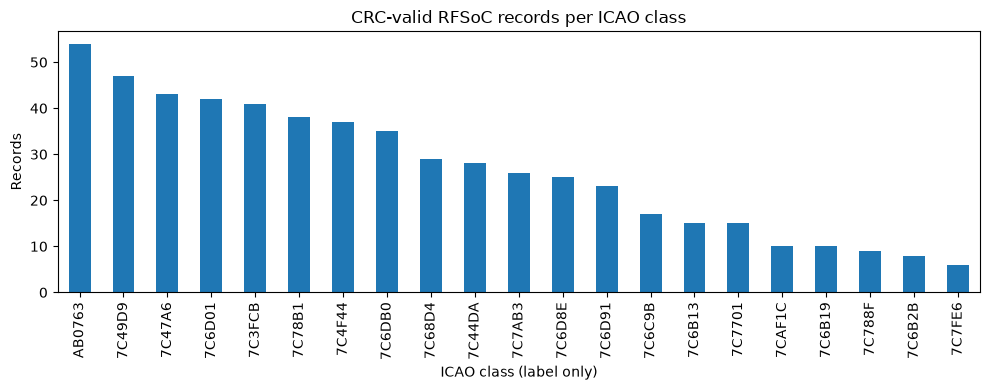

In [6]:
# Dataset audit before model preparation.
valid_records = records.loc[records["decode_ok"]].copy()
valid_records["icao"] = valid_records["icao"].astype(str)

print("Capture start:", valid_records["timestamp"].min())
print("Capture end:  ", valid_records["timestamp"].max())
print("Unique payloads:", valid_records["payload_hash"].nunique())
print("Repeated records:", len(valid_records) - valid_records["payload_hash"].nunique())

class_counts = valid_records["icao"].value_counts()
display(class_counts.rename("records").to_frame())

plt.figure(figsize=(10, 4))
class_counts.sort_values(ascending=False).plot(kind="bar")
plt.title("CRC-valid RFSoC records per ICAO class")
plt.xlabel("ICAO class (label only)")
plt.ylabel("Records")
plt.tight_layout()
plt.show()


## Payload-free input

At 10 MSPS the fixed 8 microsecond preamble is samples 0--79. Pulse windows start at samples 0, 10, 35 and 45. The payload starts at sample 80.


In [7]:
# Build the content-free preamble tensor and engineered physical features.
# Mode S preamble pulse starts are 0, 1.0, 3.5 and 4.5 microseconds.
# At 0.5 microseconds per half-symbol these are indices 0, 2, 7 and 9.
PREAMBLE_PULSE_START_US = np.array([0.0, 1.0, 3.5, 4.5])
PREAMBLE_HALVES = np.zeros(CONFIG["preamble_half_symbols"], dtype=bool)
PREAMBLE_HALVES[(PREAMBLE_PULSE_START_US / 0.5).astype(int)] = True
PREAMBLE_ACTIVE_MASK = np.repeat(
    PREAMBLE_HALVES, CONFIG["samples_per_half_symbol"]
)
ACTIVE_HALF_INDICES = np.flatnonzero(PREAMBLE_HALVES)
assert ACTIVE_HALF_INDICES.tolist() == [0, 2, 7, 9]


def normalise_preamble(iq, config=CONFIG):
    # The payload is discarded at the first line of the learning path.
    preamble = np.asarray(iq[:config["preamble_len"]], dtype=np.complex64).copy()
    if len(preamble) != config["preamble_len"]:
        raise ValueError("Record is too short for the fixed ADS-B preamble")

    quiet = preamble[~PREAMBLE_ACTIVE_MASK]
    dc = np.mean(quiet)
    preamble -= dc

    active_mean = np.mean(preamble[PREAMBLE_ACTIVE_MASK])
    phase = np.angle(active_mean) if abs(active_mean) > 1e-12 else 0.0
    preamble *= np.exp(-1j * phase)

    scale = np.sqrt(np.mean(np.abs(preamble[PREAMBLE_ACTIVE_MASK]) ** 2)) + 1e-12
    return (preamble / scale).astype(np.complex64)


def moment_features(values):
    values = np.asarray(values, dtype=np.float64)
    mean = values.mean()
    std = values.std() + 1e-12
    z = (values - mean) / std
    return float(mean), float(std), float(np.mean(z ** 3)), float(np.mean(z ** 4))


def circular_mean(values):
    return float(np.angle(np.mean(np.exp(1j * values))))


def extract_preamble_features(preamble, config=CONFIG):
    active = preamble[PREAMBLE_ACTIVE_MASK]
    quiet = preamble[~PREAMBLE_ACTIVE_MASK]
    pulse_matrix = np.stack([
        preamble[
            half_index * config["samples_per_half_symbol"]:
            (half_index + 1) * config["samples_per_half_symbol"]
        ]
        for half_index in ACTIVE_HALF_INDICES
    ])

    active_amp = np.abs(active)
    quiet_amp = np.abs(quiet)
    amp_mean, amp_std, amp_skew, amp_kurtosis = moment_features(active_amp)

    phase_steps = np.angle(pulse_matrix[:, 1:] * np.conj(pulse_matrix[:, :-1])).ravel()
    mean_phase_step = circular_mean(phase_steps)
    centred_steps = np.angle(np.exp(1j * (phase_steps - mean_phase_step)))
    cfo_hz = mean_phase_step * config["sample_rate_hz"] / (2 * np.pi)

    i_power = float(np.mean(active.real ** 2)) + 1e-12
    q_power = float(np.mean(active.imag ** 2)) + 1e-12
    iq_corr = float(np.corrcoef(active.real, active.imag)[0, 1])
    if not np.isfinite(iq_corr):
        iq_corr = 0.0

    pulse_prototype = pulse_matrix.mean(axis=0)
    pulse_amplitude = np.abs(pulse_matrix).mean(axis=0)
    pulse_phase = np.angle(pulse_prototype)
    per_pulse_power = np.mean(np.abs(pulse_matrix) ** 2, axis=1)

    feature_values = [
        amp_mean,
        amp_std,
        amp_skew,
        amp_kurtosis,
        float(active_amp.max() / (np.sqrt(np.mean(active_amp ** 2)) + 1e-12)),
        float(np.mean(active_amp ** 2)),
        float(np.mean(quiet_amp ** 2)),
        float(10 * np.log10((np.mean(active_amp ** 2) + 1e-12) /
                            (np.mean(quiet_amp ** 2) + 1e-12))),
        cfo_hz,
        float(np.std(centred_steps)),
        float(10 * np.log10(i_power / q_power)),
        iq_corr,
        float(np.std(per_pulse_power) / (np.mean(per_pulse_power) + 1e-12)),
    ]
    feature_values.extend(pulse_amplitude.tolist())
    feature_values.extend(pulse_prototype.real.tolist())
    feature_values.extend(pulse_prototype.imag.tolist())
    feature_values.extend(pulse_phase.tolist())
    return np.asarray(feature_values, dtype=np.float32)


FEATURE_NAMES = [
    "active_amplitude_mean", "active_amplitude_std", "active_amplitude_skew",
    "active_amplitude_kurtosis", "crest_factor", "active_power", "quiet_power",
    "preamble_snr_db", "carrier_offset_hz", "phase_step_std",
    "iq_power_imbalance_db", "iq_correlation", "pulse_power_variation",
]
FEATURE_NAMES += [f"pulse_amplitude_{i}" for i in range(5)]
FEATURE_NAMES += [f"pulse_i_{i}" for i in range(5)]
FEATURE_NAMES += [f"pulse_q_{i}" for i in range(5)]
FEATURE_NAMES += [f"pulse_phase_{i}" for i in range(5)]


def iq_to_channels(iq):
    return np.stack([iq.real, iq.imag], axis=0).astype(np.float32)


def prepare_model_table(records_df, config=CONFIG):
    df = records_df.loc[records_df["decode_ok"]].copy()
    counts = df["icao"].value_counts()
    keep = counts[counts >= config["min_records_per_class"]].index
    df = df[df["icao"].isin(keep)].copy()

    if config["max_records_per_class"] is not None:
        df = (
            df.sample(frac=1, random_state=config["random_seed"])
              .groupby("icao", sort=False, group_keys=False)
              .head(config["max_records_per_class"])
        )

    preambles = []
    features = []
    for iq in df["iq"]:
        preamble = normalise_preamble(iq, config)
        preambles.append(iq_to_channels(preamble))
        features.append(extract_preamble_features(preamble, config))

    model_metadata = df[[
        "record_index", "timestamp", "icao", "payload_hash"
    ]].reset_index(drop=True)
    return (
        np.stack(preambles),
        np.stack(features),
        model_metadata,
    )


X_preamble, X_physical, model_metadata = prepare_model_table(records, CONFIG)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(model_metadata["icao"])
class_names = list(label_encoder.classes_)

assert X_preamble.shape[1:] == (2, CONFIG["preamble_len"])
assert X_preamble.shape[-1] < CONFIG["record_len"]
assert X_physical.shape[1] == len(FEATURE_NAMES)

print("Payload-free I/Q tensor:", X_preamble.shape)
print("Physical feature matrix:", X_physical.shape)
print("Classes:", len(class_names))


# Three-channel time-series image for MobileNet.
# Each channel is an 80 x 80 recurrence plot for I, Q or magnitude.
def make_recurrence_images(preambles):
    i = preambles[:, 0]
    q = preambles[:, 1]
    magnitude = np.sqrt(i ** 2 + q ** 2)
    channels = np.stack([i, q, magnitude], axis=1)
    images = np.abs(channels[:, :, :, None] - channels[:, :, None, :])
    scales = images.reshape(len(images), 3, -1).max(axis=2)[:, :, None, None]
    return (images / (scales + 1e-12)).astype(np.float32)

X_recurrence = make_recurrence_images(X_preamble)
assert X_recurrence.shape == (len(X_preamble), 3, 80, 80)
print("Recurrence image tensor:", X_recurrence.shape)


Payload-free I/Q tensor: (558, 2, 80)
Physical feature matrix: (558, 33)
Classes: 21
Recurrence image tensor: (558, 3, 80, 80)


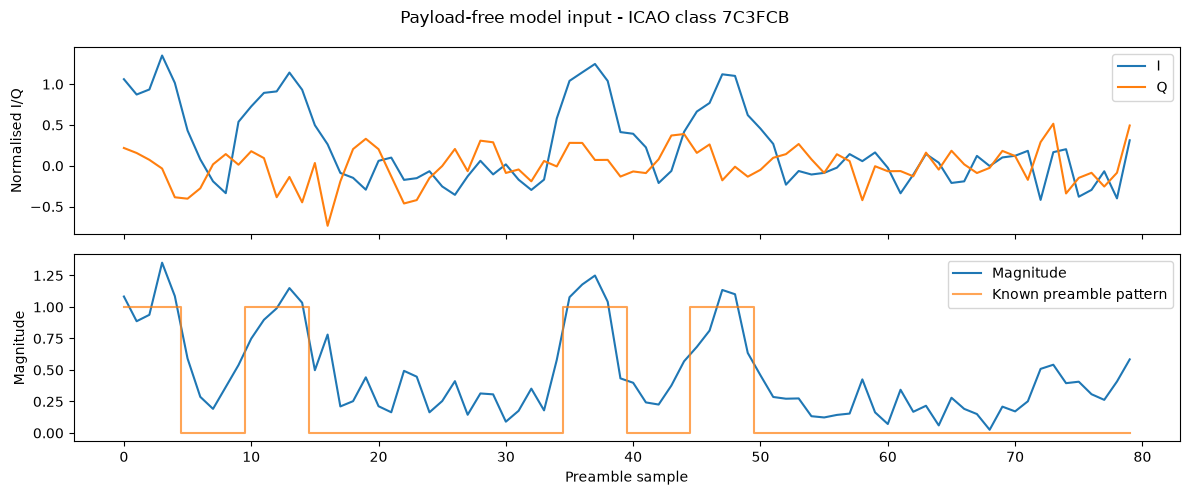

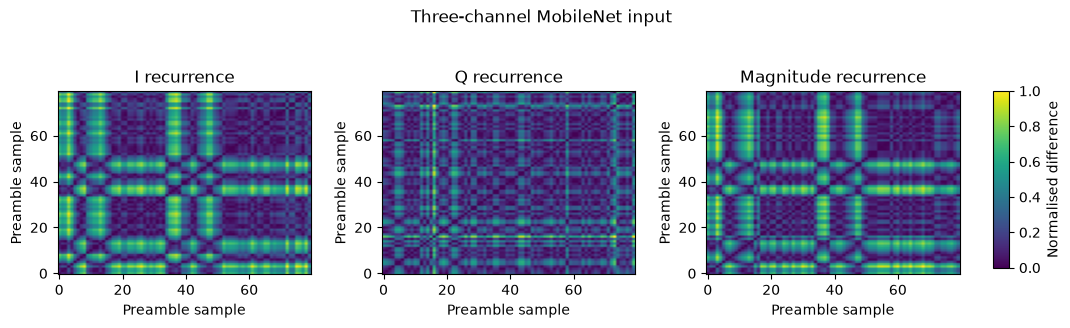

In [8]:
# Example inputs. Both stop before the payload.
figure_dir = Path("notes/figures/cr_ml")
figure_dir.mkdir(parents=True, exist_ok=True)
example_idx = 0

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(X_preamble[example_idx, 0], label="I")
axes[0].plot(X_preamble[example_idx, 1], label="Q")
axes[0].set_ylabel("Normalised I/Q")
axes[0].legend()
axes[1].plot(np.sqrt(np.sum(X_preamble[example_idx] ** 2, axis=0)), label="Magnitude")
axes[1].step(
    np.arange(CONFIG["preamble_len"]),
    PREAMBLE_ACTIVE_MASK.astype(float),
    where="mid",
    label="Known preamble pattern",
    alpha=0.7,
)
axes[1].set_xlabel("Preamble sample")
axes[1].set_ylabel("Magnitude")
axes[1].legend()
fig.suptitle(f"Payload-free model input - ICAO class {model_metadata.loc[example_idx, 'icao']}")
plt.tight_layout()
fig.savefig(figure_dir / "06_09_26_preamble_input.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for axis, image, title in zip(
    axes,
    X_recurrence[example_idx],
    ["I recurrence", "Q recurrence", "Magnitude recurrence"],
):
    plot = axis.imshow(image, origin="lower", aspect="auto", vmin=0, vmax=1)
    axis.set_title(title)
    axis.set_xlabel("Preamble sample")
    axis.set_ylabel("Preamble sample")
fig.subplots_adjust(left=0.06, right=0.88, bottom=0.18, top=0.72, wspace=0.28)
colour_axis = fig.add_axes([0.91, 0.20, 0.015, 0.52])
fig.colorbar(plot, cax=colour_axis, label="Normalised difference")
fig.suptitle("Three-channel MobileNet input", y=0.96)
fig.savefig(figure_dir / "06_09_26_recurrence_input.png", dpi=180, bbox_inches="tight")
plt.show()


### I/Q check

The left plot in each pair is DC corrected and scaled. The right plot includes the phase alignment used by the models.


All-record median raw Q energy: 51.3%
All-record median model-input Q energy: 20.5%


,icao,raw_q_energy_percent,model_q_energy_percent
0,7C3FCB,47.099998,9.300000
1,7C44DA,62.200001,10.500000
2,7C47A6,50.900002,38.799999
3,7C49D9,48.900002,26.000000
4,7C4F44,56.599998,18.900000
5,7C68D4,49.700001,52.900002
6,7C6B13,48.299999,38.000000
7,7C6B19,52.099998,56.000000
8,7C6B2B,51.099998,65.099998
9,7C6C9B,54.500000,57.299999


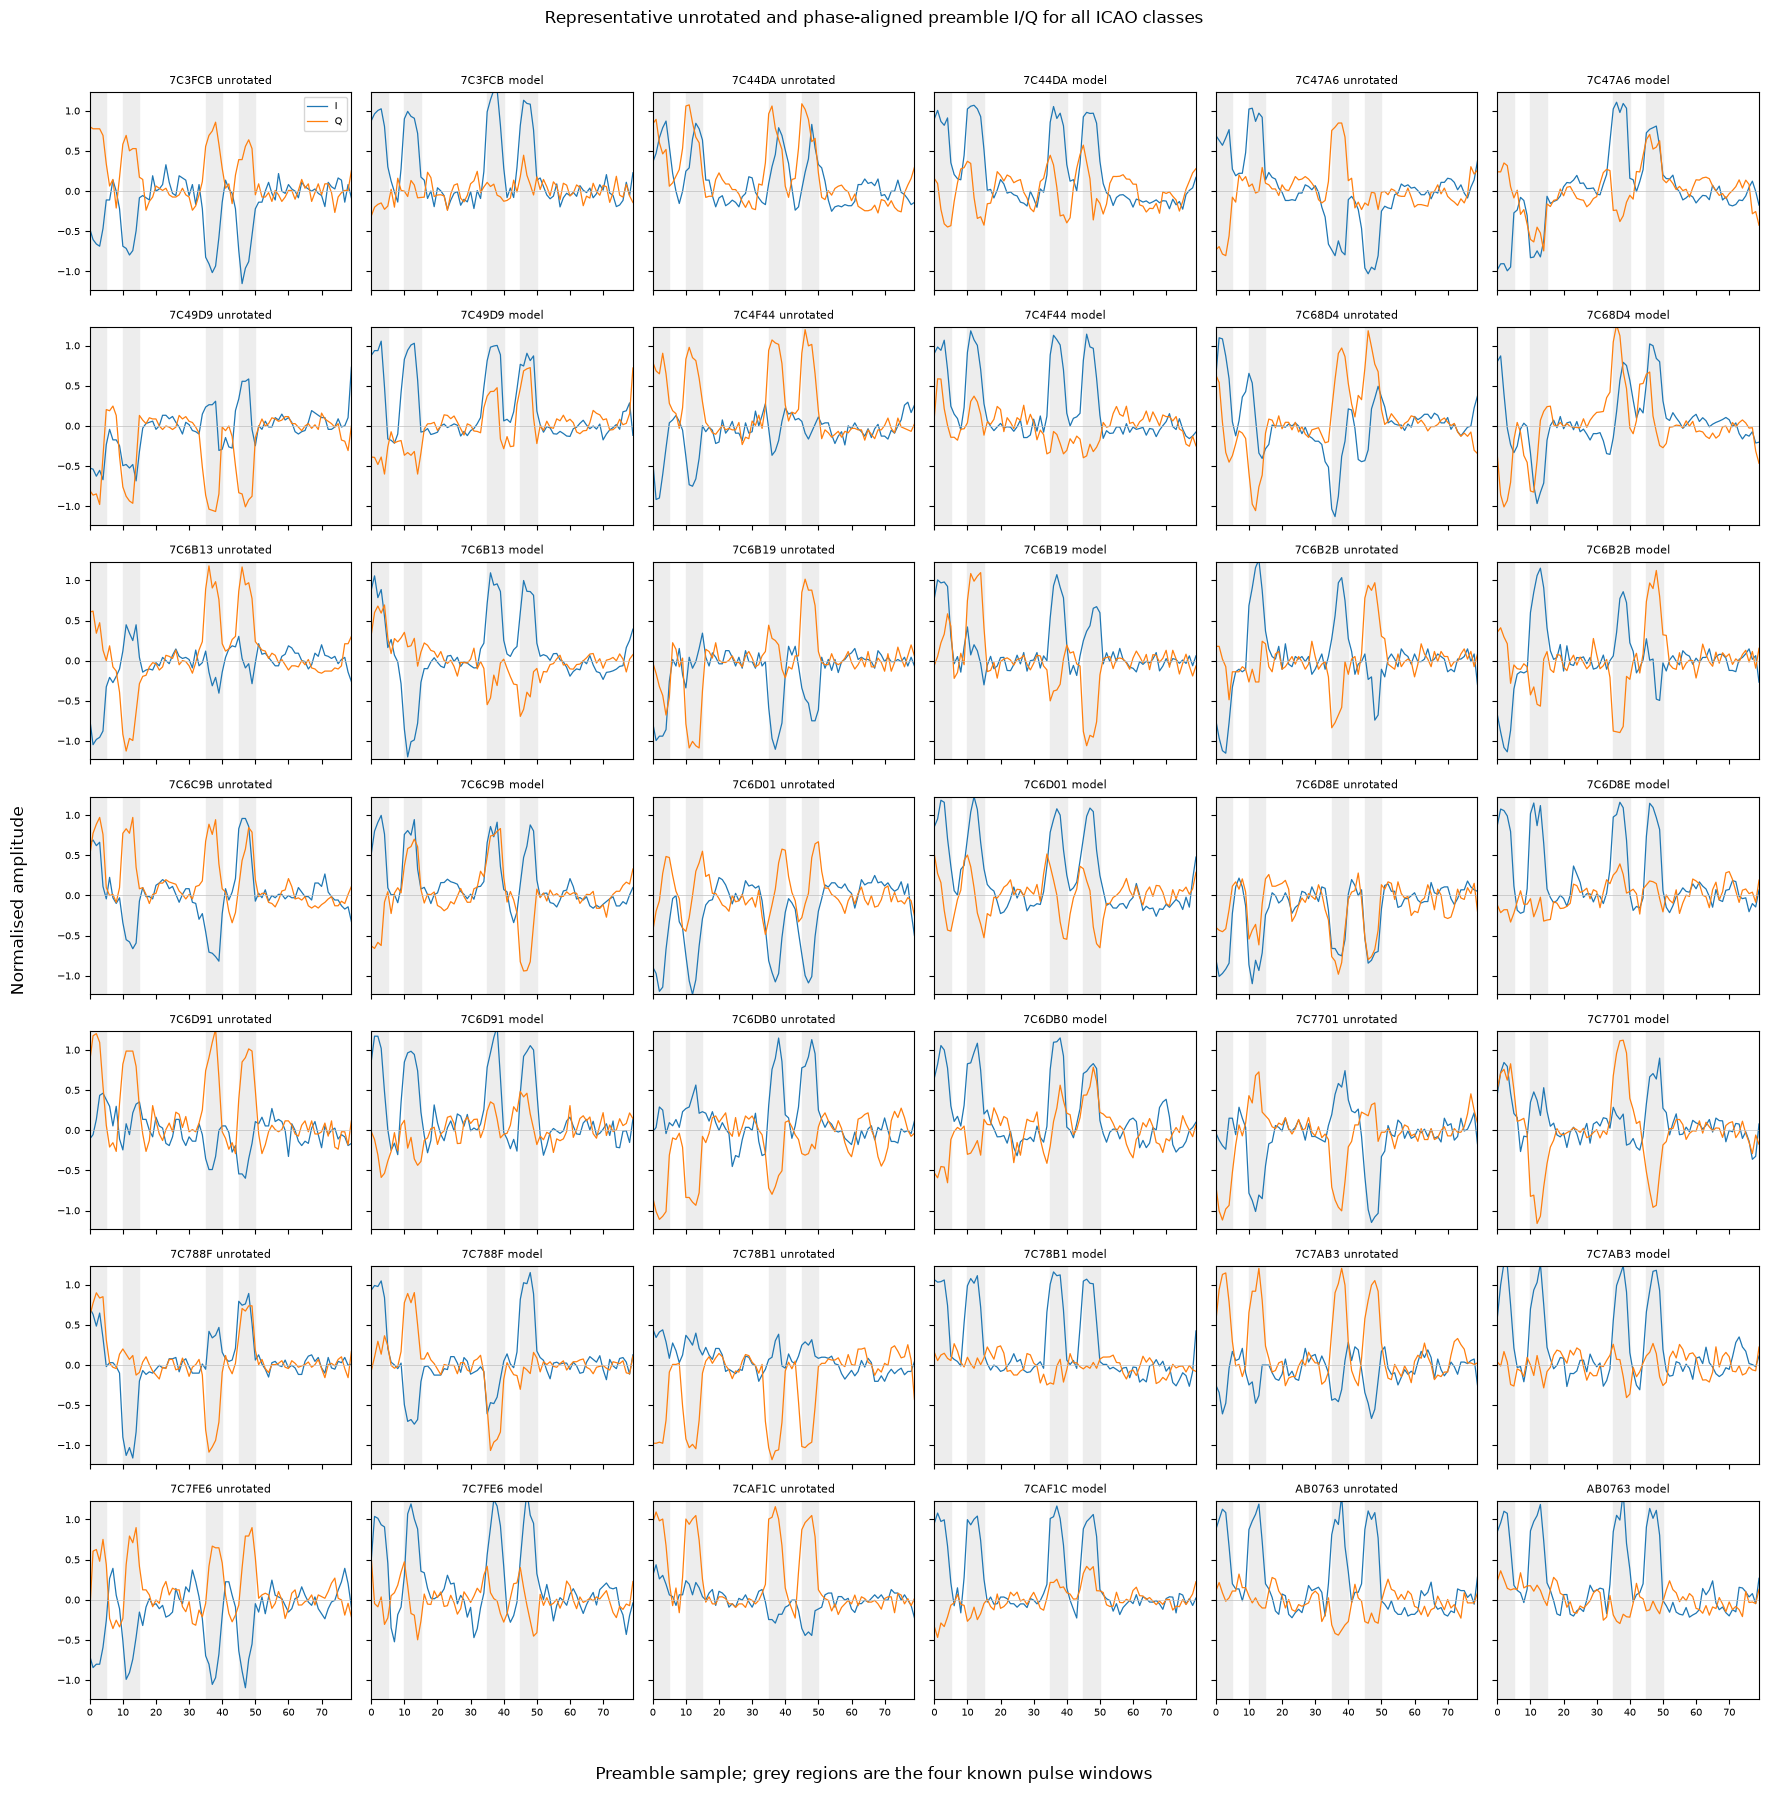

In [9]:
def preamble_without_phase_alignment(iq, config=CONFIG):
    preamble = np.asarray(iq[:config["preamble_len"]], dtype=np.complex64).copy()
    preamble -= np.mean(preamble[~PREAMBLE_ACTIVE_MASK])
    scale = np.sqrt(np.mean(np.abs(preamble[PREAMBLE_ACTIVE_MASK]) ** 2)) + 1e-12
    return (preamble / scale).astype(np.complex64)


iq_by_record = records.set_index("record_index")["iq"].to_dict()
raw_preambles = np.stack([
    preamble_without_phase_alignment(iq_by_record[index])
    for index in model_metadata["record_index"]
])
model_preambles = X_preamble[:, 0] + 1j * X_preamble[:, 1]

raw_q_fraction = np.mean(raw_preambles.imag ** 2, axis=1) / (
    np.mean(np.abs(raw_preambles) ** 2, axis=1) + 1e-12
)
model_q_fraction = np.mean(model_preambles.imag ** 2, axis=1) / (
    np.mean(np.abs(model_preambles) ** 2, axis=1) + 1e-12
)
iq_channel_summary = model_metadata[["icao"]].copy()
iq_channel_summary["raw_q_energy_percent"] = 100 * raw_q_fraction
iq_channel_summary["model_q_energy_percent"] = 100 * model_q_fraction
iq_channel_summary = (
    iq_channel_summary.groupby("icao", sort=True)
    .median()
    .reset_index()
)
print(f"All-record median raw Q energy: {100 * np.median(raw_q_fraction):.1f}%")
print(f"All-record median model-input Q energy: {100 * np.median(model_q_fraction):.1f}%")
display(iq_channel_summary.round(1))

representative_indices = {}
icao_values = model_metadata["icao"].to_numpy()
for icao in class_names:
    indices = np.flatnonzero(icao_values == icao)
    magnitudes = np.abs(model_preambles[indices])
    median_magnitude = np.median(magnitudes, axis=0)
    representative_indices[icao] = indices[
        np.argmin(np.mean((magnitudes - median_magnitude) ** 2, axis=1))
    ]

fig, axes = plt.subplots(7, 6, figsize=(18, 18), sharex=True, sharey=True)
pulse_starts = ACTIVE_HALF_INDICES * CONFIG["samples_per_half_symbol"]
display_limit = np.quantile(
    np.abs(np.concatenate([raw_preambles.real.ravel(), raw_preambles.imag.ravel()])),
    0.995,
)

for class_position, icao in enumerate(class_names):
    row = class_position // 3
    pair_column = 2 * (class_position % 3)
    record_position = representative_indices[icao]
    raw = raw_preambles[record_position]
    model = model_preambles[record_position]

    for axis, values, suffix in [
        (axes[row, pair_column], raw, "unrotated"),
        (axes[row, pair_column + 1], model, "model"),
    ]:
        for start in pulse_starts:
            axis.axvspan(start, start + CONFIG["samples_per_half_symbol"], color="0.93", zorder=0)
        axis.plot(values.real, label="I", linewidth=0.9)
        axis.plot(values.imag, label="Q", linewidth=0.9)
        axis.axhline(0, color="0.75", linewidth=0.5)
        axis.set_title(f"{icao} {suffix}", fontsize=8)
        axis.set_xlim(0, CONFIG["preamble_len"] - 1)
        axis.set_ylim(-display_limit, display_limit)
        axis.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=7, loc="upper right")
fig.supxlabel("Preamble sample; grey regions are the four known pulse windows")
fig.supylabel("Normalised amplitude")
fig.suptitle("Representative unrotated and phase-aligned preamble I/Q for all ICAO classes", y=0.995)
plt.tight_layout(rect=(0.02, 0.02, 1, 0.985))
fig.savefig(figure_dir / "06_09_26_all_classes_iq.png", dpi=160, bbox_inches="tight")
plt.show()


## Grouped folds

Use flight/session IDs when available. This file has no manifest, so the fallback groups nearby records and duplicate payloads. It is an exploratory within-capture test.


In [10]:
# Optional session manifest and connected-component grouping.

def add_session_manifest(metadata, manifest_path):
    metadata = metadata.copy()
    metadata["session_id"] = pd.NA
    if manifest_path is None:
        return metadata, False

    manifest = pd.read_csv(manifest_path)
    required = {"record_index", "session_id"}
    if not required.issubset(manifest.columns):
        raise ValueError(f"Session manifest must contain {sorted(required)}")
    metadata = metadata.drop(columns="session_id").merge(
        manifest[["record_index", "session_id"]],
        on="record_index",
        how="left",
        validate="one_to_one",
    )
    if metadata["session_id"].isna().any():
        missing = metadata.loc[metadata["session_id"].isna(), "record_index"].tolist()[:10]
        raise ValueError(f"Session IDs missing for record indices such as {missing}")
    return metadata, True


def connected_groups(metadata, use_sessions, config=CONFIG):
    group_ids = np.empty(len(metadata), dtype=object)

    for icao, class_frame in metadata.groupby("icao", sort=True):
        positions = class_frame.index.to_numpy()
        local_index = {global_idx: i for i, global_idx in enumerate(positions)}
        parent = list(range(len(positions)))

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i

        def union(a, b):
            root_a, root_b = find(a), find(b)
            if root_a != root_b:
                parent[root_b] = root_a

        # Exact repeated payloads must never straddle folds.
        for _, same_payload in class_frame.groupby("payload_hash"):
            members = same_payload.index.to_list()
            for member in members[1:]:
                union(local_index[members[0]], local_index[member])

        if use_sessions:
            for _, same_session in class_frame.groupby("session_id"):
                members = same_session.index.to_list()
                for member in members[1:]:
                    union(local_index[members[0]], local_index[member])
        else:
            ordered = class_frame.sort_values("timestamp").index.to_list()
            for left, right in zip(ordered, ordered[1:]):
                delta = (
                    metadata.loc[right, "timestamp"] - metadata.loc[left, "timestamp"]
                ).total_seconds()
                if delta <= config["temporal_group_gap_seconds"]:
                    union(local_index[left], local_index[right])

        roots = {}
        for global_idx in positions:
            root = find(local_index[global_idx])
            roots.setdefault(root, len(roots))
            group_ids[global_idx] = f"{icao}:group_{roots[root]:03d}"

    return group_ids


model_metadata, using_independent_sessions = add_session_manifest(
    model_metadata, CONFIG["session_manifest_path"]
)
groups = connected_groups(model_metadata, using_independent_sessions, CONFIG)
model_metadata["group_id"] = groups

groups_per_class = model_metadata.groupby("icao")["group_id"].nunique()
display(pd.DataFrame({
    "records": model_metadata["icao"].value_counts(),
    "groups": groups_per_class,
}).sort_values("records", ascending=False))

n_splits = min(CONFIG["requested_folds"], int(groups_per_class.min()))
if len(class_names) < 2 or n_splits < 2:
    raise ValueError(
        "Grouped validation is not possible: every class needs at least two independent "
        "groups. Collect another session/pass rather than reverting to record-level splitting."
    )

evidence_grade = (
    "independent-session grouped evaluation"
    if using_independent_sessions
    else "exploratory within-capture burst-group evaluation"
)
print("Validation:", evidence_grade)
print(f"Using {n_splits} folds (requested {CONFIG['requested_folds']}).")


,records,groups
icao,,
AB0763,54,5
7C49D9,47,2
7C47A6,43,6
7C6D01,42,2
7C3FCB,41,9
7C78B1,38,8
7C4F44,37,5
7C6DB0,35,3
7C68D4,29,3


Validation: exploratory within-capture burst-group evaluation
Using 2 folds (requested 5).


In [11]:
# Deterministic class-stratified assignment of single-class groups to folds.
# This guarantees that every class is represented in every evaluation fold.

def make_stratified_group_folds(labels, group_ids, n_splits, seed):
    labels = np.asarray(labels)
    group_ids = np.asarray(group_ids)
    rng = np.random.default_rng(seed)
    fold_groups = [set() for _ in range(n_splits)]
    global_fold_load = np.zeros(n_splits, dtype=int)

    for class_id in np.unique(labels):
        class_mask = labels == class_id
        class_groups, counts = np.unique(group_ids[class_mask], return_counts=True)
        order = rng.permutation(len(class_groups))
        class_groups = class_groups[order]
        counts = counts[order]
        size_order = np.argsort(-counts, kind="stable")
        class_fold_load = np.zeros(n_splits, dtype=int)

        for group_id, group_size in zip(class_groups[size_order], counts[size_order]):
            least_class_load = class_fold_load.min()
            candidates = np.flatnonzero(class_fold_load == least_class_load)
            fold = int(candidates[np.argmin(global_fold_load[candidates])])
            fold_groups[fold].add(group_id)
            class_fold_load[fold] += int(group_size)
            global_fold_load[fold] += int(group_size)

    folds = []
    for fold, validation_groups in enumerate(fold_groups):
        val_mask = np.isin(group_ids, list(validation_groups))
        val_idx = np.flatnonzero(val_mask)
        train_idx = np.flatnonzero(~val_mask)
        folds.append((train_idx, val_idx))
    return folds


folds = make_stratified_group_folds(
    y, groups, n_splits=n_splits, seed=CONFIG["random_seed"]
)


def minimum_same_class_time_separation(train_idx, val_idx):
    minima = []
    timestamps = model_metadata["timestamp"].to_numpy()
    for class_id in np.unique(y):
        train_times = timestamps[train_idx[y[train_idx] == class_id]]
        val_times = timestamps[val_idx[y[val_idx] == class_id]]
        if len(train_times) and len(val_times):
            distances = [
                abs((pd.Timestamp(a) - pd.Timestamp(b)).total_seconds())
                for a in train_times for b in val_times
            ]
            minima.append(min(distances))
    return min(minima) if minima else np.nan


fold_audit_rows = []
for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    train_groups = set(groups[train_idx])
    val_groups = set(groups[val_idx])
    train_hashes = set(model_metadata.loc[train_idx, "payload_hash"])
    val_hashes = set(model_metadata.loc[val_idx, "payload_hash"])

    assert train_groups.isdisjoint(val_groups)
    assert train_hashes.isdisjoint(val_hashes)
    assert set(y[train_idx]) == set(range(len(class_names)))
    assert set(y[val_idx]) == set(range(len(class_names)))

    fold_audit_rows.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_validation": len(val_idx),
        "train_classes": len(np.unique(y[train_idx])),
        "validation_classes": len(np.unique(y[val_idx])),
        "group_overlap": len(train_groups & val_groups),
        "payload_hash_overlap": len(train_hashes & val_hashes),
        "minimum_same_class_time_separation_s": minimum_same_class_time_separation(
            train_idx, val_idx
        ),
    })

fold_audit = pd.DataFrame(fold_audit_rows)
display(fold_audit)

assert fold_audit["group_overlap"].eq(0).all()
assert fold_audit["payload_hash_overlap"].eq(0).all()


,fold,n_train,n_validation,train_classes,validation_classes,group_overlap,payload_hash_overlap,minimum_same_class_time_separation_s
0,1,297,261,21,21,0,0,5.025566
1,2,261,297,21,21,0,0,5.025566


In [12]:
# Check the model inputs.
learning_input_audit = pd.DataFrame([
    {
        "input": "normalised preamble I/Q",
        "shape_per_record": str(tuple(X_preamble.shape[1:])),
        "original_sample_range": "0-79",
        "payload_samples_present": False,
    },
    {
        "input": "33 physical preamble features",
        "shape_per_record": str(tuple(X_physical.shape[1:])),
        "original_sample_range": "derived from 0-79",
        "payload_samples_present": False,
    },
    {
        "input": "I/Q/magnitude recurrence image",
        "shape_per_record": str(tuple(X_recurrence.shape[1:])),
        "original_sample_range": "derived from 0-79",
        "payload_samples_present": False,
    },
])
display(learning_input_audit)

payload_start = CONFIG["preamble_len"]
icao_payload_sample_start = payload_start + 8 * 2 * CONFIG["samples_per_half_symbol"]
icao_payload_sample_stop = payload_start + 32 * 2 * CONFIG["samples_per_half_symbol"]
print("Payload starts at sample", payload_start)
print("ICAO-bearing payload samples:", icao_payload_sample_start, "to", icao_payload_sample_stop - 1)
print("Latest model-input sample: 79")
assert X_preamble.shape[-1] <= payload_start


,input,shape_per_record,original_sample_range,payload_samples_present
0,normalised preamble I/Q,"(2, 80)",0-79,False
1,33 physical preamble features,"(33,)",derived from 0-79,False
2,I/Q/magnitude recurrence image,"(3, 80, 80)",derived from 0-79,False


Payload starts at sample 80
ICAO-bearing payload samples: 160 to 399
Latest model-input sample: 79


## Models

- SVM and random forest use 33 physical preamble features.
- CNN, TCN and GRU use the $2\times80$ I/Q sequence.
- Both MobileNet runs use the same $3\times80\times80$ recurrence image.
- The transfer run starts from ImageNet-1K weights and keeps the convolutional feature extractor frozen.


In [13]:
# Neural model definitions.
class ArrayDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.as_tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index] if self.y is None else (self.X[index], self.y[index])


class PreambleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        c1, c2, c3 = CONFIG["cnn_channels"]
        self.network = nn.Sequential(
            nn.Conv1d(2, c1, 7, padding=3), nn.BatchNorm1d(c1), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(c1, c2, 5, padding=2), nn.BatchNorm1d(c2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(c2, c3, 3, padding=1), nn.BatchNorm1d(c3), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(CONFIG["dropout"]),
            nn.Linear(c3, num_classes),
        )

    def forward(self, x):
        return self.network(x)


class TCNBlock(nn.Module):
    def __init__(self, channels, dilation):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm1d(channels), nn.ReLU(), nn.Dropout(CONFIG["dropout"] * 0.5),
            nn.Conv1d(channels, channels, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm1d(channels),
        )
        self.activation = nn.ReLU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class PreambleTCN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        channels = CONFIG["tcn_channels"]
        self.input = nn.Conv1d(2, channels, 1)
        self.blocks = nn.Sequential(*(TCNBlock(channels, d) for d in (1, 2, 4)))
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(CONFIG["dropout"]),
            nn.Linear(channels, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.blocks(self.input(x)))


class PreambleGRU(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.gru = nn.GRU(2, CONFIG["gru_hidden"], batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.LayerNorm(2 * CONFIG["gru_hidden"]), nn.Dropout(CONFIG["dropout"]),
            nn.Linear(2 * CONFIG["gru_hidden"], num_classes),
        )

    def forward(self, x):
        _, hidden = self.gru(x.transpose(1, 2))
        return self.classifier(torch.cat([hidden[-2], hidden[-1]], dim=1))


class MobileNetPreamble(nn.Module):
    def __init__(self, num_classes, pretrained=False, freeze_features=False):
        super().__init__()
        weights = MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        self.network = mobilenet_v3_small(weights=weights, progress=False)
        in_features = self.network.classifier[-1].in_features
        self.network.classifier[-1] = nn.Linear(in_features, num_classes)
        self.freeze_features = freeze_features
        if freeze_features:
            for parameter in self.network.features.parameters():
                parameter.requires_grad = False
        self.register_buffer("image_mean", torch.tensor([0.485, 0.456, 0.406])[None, :, None, None])
        self.register_buffer("image_std", torch.tensor([0.229, 0.224, 0.225])[None, :, None, None])

    def train(self, mode=True):
        super().train(mode)
        if self.freeze_features:
            self.network.features.eval()
        return self

    def forward(self, x):
        return self.network((x - self.image_mean) / self.image_std)


MODEL_NAMES = {
    "physical_feature_svm": "Physical-feature RBF SVM",
    "physical_feature_random_forest": "Physical-feature random forest",
    "preamble_cnn": "1D preamble CNN",
    "preamble_tcn": "Temporal convolutional network",
    "preamble_gru_rnn": "Bidirectional GRU RNN",
    "mobilenet_scratch": "MobileNetV3-Small from scratch",
    "imagenet_transfer_mobilenet": "ImageNet transfer MobileNetV3-Small",
}

def torch_model_spec(experiment, model, input_name, weight_source):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "experiment": experiment,
        "model": MODEL_NAMES[experiment],
        "input": input_name,
        "weight_source": weight_source,
        "total_parameters": total,
        "trainable_parameters": trainable,
        "parameter_memory_mb": total * 4 / 1e6,
    }

spec_models = {
    "preamble_cnn": PreambleCNN(len(class_names)),
    "preamble_tcn": PreambleTCN(len(class_names)),
    "preamble_gru_rnn": PreambleGRU(len(class_names)),
    "mobilenet_scratch": MobileNetPreamble(len(class_names), pretrained=False, freeze_features=False),
    "imagenet_transfer_mobilenet": MobileNetPreamble(len(class_names), pretrained=False, freeze_features=True),
}
model_specs_df = pd.DataFrame([
    torch_model_spec(
        name,
        model,
        "2 x 80 I/Q" if "preamble" in name else "3 x 80 x 80 recurrence image",
        "ImageNet-1K" if name == "imagenet_transfer_mobilenet" else "random initialisation",
    )
    for name, model in spec_models.items()
])
display(model_specs_df)
del spec_models


,experiment,model,input,weight_source,total_parameters,trainable_parameters,parameter_memory_mb
0,preamble_cnn,1D preamble CNN,2 x 80 I/Q,random initialisation,31733,31733,0.126932
1,preamble_tcn,Temporal convolutional network,2 x 80 I/Q,random initialisation,43509,43509,0.174036
2,preamble_gru_rnn,Bidirectional GRU RNN,2 x 80 I/Q,random initialisation,29077,29077,0.116308
3,mobilenet_scratch,MobileNetV3-Small from scratch,3 x 80 x 80 recurrence image,random initialisation,1539381,1539381,6.157524
4,imagenet_transfer_mobilenet,ImageNet transfer MobileNetV3-Small,3 x 80 x 80 recurrence image,ImageNet-1K,1539381,612373,6.157524


In [14]:
# Training helpers.
def make_loader(X, labels=None, shuffle=False):
    return DataLoader(
        ArrayDataset(X, labels),
        batch_size=CONFIG["batch_size"],
        shuffle=shuffle,
        num_workers=0,
    )

def class_weights(train_labels, num_classes):
    counts = np.bincount(train_labels, minlength=num_classes).astype(np.float32)
    weights = counts.sum() / (num_classes * np.maximum(counts, 1.0))
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

def train_supervised(model, X_train, y_train, seed, epochs, learning_rate):
    set_seed(seed)
    model = model.to(DEVICE)
    loader = make_loader(X_train, y_train, shuffle=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights(y_train, len(class_names)))
    parameters = [p for p in model.parameters() if p.requires_grad]
    optimiser = torch.optim.AdamW(parameters, lr=learning_rate, weight_decay=CONFIG["weight_decay"])
    history = []
    for _ in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimiser.step()
            total_loss += loss.item() * len(yb)
        history.append(total_loss / len(loader.dataset))
    return model, history

@torch.no_grad()
def predict(model, X):
    model.eval()
    outputs = []
    for xb in make_loader(X):
        outputs.append(torch.argmax(model(xb.to(DEVICE)), dim=1).cpu().numpy())
    return np.concatenate(outputs)

def score_predictions(targets, predictions):
    return {
        "accuracy": accuracy_score(targets, predictions),
        "balanced_accuracy": balanced_accuracy_score(targets, predictions),
        "macro_f1": f1_score(targets, predictions, average="macro", zero_division=0),
    }

def torch_complexity(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable, total * 4 / 1e6


In [15]:
# Run every model on the same folds.
experiment_rows = []
prediction_rows = []
complexity_rows = []
training_histories = {}

for fold_number, (train_idx, val_idx) in enumerate(folds, start=1):
    print(f"Fold {fold_number}/{n_splits}")
    for experiment_number, experiment in enumerate(CONFIG["experiments"]):
        seed = CONFIG["random_seed"] + 100 * fold_number + experiment_number
        set_seed(seed)
        history = None

        if experiment == "physical_feature_svm":
            model = Pipeline([
                ("scale", StandardScaler()),
                ("svm", SVC(C=3.0, kernel="rbf", gamma="scale", class_weight="balanced")),
            ])
            model.fit(X_physical[train_idx], y[train_idx])
            predictions = model.predict(X_physical[val_idx])
            fitted = model.named_steps["svm"]
            complexity_rows.append({
                "experiment": experiment,
                "fold": fold_number,
                "total_parameters": np.nan,
                "trainable_parameters": np.nan,
                "parameter_memory_mb": np.nan,
                "support_vectors": fitted.support_vectors_.shape[0],
                "tree_nodes": np.nan,
                "fitted_size_mb": len(pickle.dumps(model)) / 1e6,
            })

        elif experiment == "physical_feature_random_forest":
            model = RandomForestClassifier(
                n_estimators=CONFIG["random_forest_trees"],
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=seed,
            )
            model.fit(X_physical[train_idx], y[train_idx])
            predictions = model.predict(X_physical[val_idx])
            complexity_rows.append({
                "experiment": experiment,
                "fold": fold_number,
                "total_parameters": np.nan,
                "trainable_parameters": np.nan,
                "parameter_memory_mb": np.nan,
                "support_vectors": np.nan,
                "tree_nodes": sum(tree.tree_.node_count for tree in model.estimators_),
                "fitted_size_mb": len(pickle.dumps(model)) / 1e6,
            })

        else:
            if experiment == "preamble_cnn":
                model, X_data, epochs, lr = PreambleCNN(len(class_names)), X_preamble, CONFIG["epochs"], CONFIG["learning_rate"]
            elif experiment == "preamble_tcn":
                model, X_data, epochs, lr = PreambleTCN(len(class_names)), X_preamble, CONFIG["epochs"], CONFIG["learning_rate"]
            elif experiment == "preamble_gru_rnn":
                model, X_data, epochs, lr = PreambleGRU(len(class_names)), X_preamble, CONFIG["epochs"], CONFIG["learning_rate"]
            elif experiment == "mobilenet_scratch":
                model = MobileNetPreamble(len(class_names), pretrained=False, freeze_features=False)
                X_data, epochs, lr = X_recurrence, CONFIG["image_epochs"], CONFIG["learning_rate"]
            elif experiment == "imagenet_transfer_mobilenet":
                model = MobileNetPreamble(len(class_names), pretrained=True, freeze_features=True)
                X_data, epochs, lr = X_recurrence, CONFIG["transfer_epochs"], CONFIG["transfer_learning_rate"]
            else:
                raise ValueError(experiment)

            model, history = train_supervised(model, X_data[train_idx], y[train_idx], seed, epochs, lr)
            predictions = predict(model, X_data[val_idx])
            total, trainable, memory_mb = torch_complexity(model)
            complexity_rows.append({
                "experiment": experiment,
                "fold": fold_number,
                "total_parameters": total,
                "trainable_parameters": trainable,
                "parameter_memory_mb": memory_mb,
                "support_vectors": np.nan,
                "tree_nodes": np.nan,
                "fitted_size_mb": memory_mb,
            })
            training_histories[(experiment, fold_number)] = history

        metrics = score_predictions(y[val_idx], predictions)
        experiment_rows.append({
            "experiment": experiment,
            "fold": fold_number,
            "validation_kind": evidence_grade,
            "n_train": len(train_idx),
            "n_validation": len(val_idx),
            **metrics,
        })
        for row_index, target, prediction in zip(val_idx, y[val_idx], predictions):
            prediction_rows.append({
                "experiment": experiment,
                "fold": fold_number,
                "record_index": int(model_metadata.loc[row_index, "record_index"]),
                "true_class": class_names[int(target)],
                "predicted_class": class_names[int(prediction)],
            })
        print(f"  {MODEL_NAMES[experiment]:38s} balanced={metrics['balanced_accuracy']:.3f} macro-F1={metrics['macro_f1']:.3f}")

results_df = pd.DataFrame(experiment_rows)
predictions_df = pd.DataFrame(prediction_rows)
complexity_df = pd.DataFrame(complexity_rows)
display(results_df)


Fold 1/2
  Physical-feature RBF SVM               balanced=0.250 macro-F1=0.195


  Physical-feature random forest         balanced=0.278 macro-F1=0.196


  1D preamble CNN                        balanced=0.405 macro-F1=0.311


  Temporal convolutional network         balanced=0.362 macro-F1=0.297


  Bidirectional GRU RNN                  balanced=0.311 macro-F1=0.271


...

  Temporal convolutional network         balanced=0.322 macro-F1=0.211


  Bidirectional GRU RNN                  balanced=0.278 macro-F1=0.180


  MobileNetV3-Small from scratch         balanced=0.048 macro-F1=0.001


  ImageNet transfer MobileNetV3-Small    balanced=0.212 macro-F1=0.112


,experiment,fold,validation_kind,n_train,n_validation,accuracy,balanced_accuracy,macro_f1
0,physical_feature_svm,1,exploratory within-capture burst-group evaluation,297,261,0.214559,0.250459,0.194631
1,physical_feature_random_forest,1,exploratory within-capture burst-group evaluation,297,261,0.210728,0.278467,0.196154
2,preamble_cnn,1,exploratory within-capture burst-group evaluation,297,261,0.337165,0.405444,0.310855
3,preamble_tcn,1,exploratory within-capture burst-group evaluation,297,261,0.325670,0.362097,0.297252
4,preamble_gru_rnn,1,exploratory within-capture burst-group evaluation,297,261,0.344828,0.311379,0.271402
5,mobilenet_scratch,1,exploratory within-capture burst-group evaluation,297,261,0.030651,0.047619,0.002832
6,imagenet_transfer_mobilenet,1,exploratory within-capture burst-group evaluation,297,261,0.157088,0.189567,0.164854
7,physical_feature_svm,2,exploratory within-capture burst-group evaluation,261,297,0.208754,0.253102,0.218837
8,physical_feature_random_forest,2,exploratory within-capture burst-group evaluation,261,297,0.228956,0.310880,0.248714
9,preamble_cnn,2,exploratory within-capture burst-group evaluation,261,297,0.249158,0.338345,0.244391


,experiment,model,accuracy,balanced_accuracy,macro_f1
0,preamble_cnn,1D preamble CNN,0.290323,0.321976,0.292324
1,preamble_tcn,Temporal convolutional network,0.272401,0.303459,0.277610
2,preamble_gru_rnn,Bidirectional GRU RNN,0.265233,0.281891,0.243090
3,physical_feature_random_forest,Physical-feature random forest,0.220430,0.226670,0.220012
4,physical_feature_svm,Physical-feature RBF SVM,0.211470,0.225361,0.209390
5,imagenet_transfer_mobilenet,ImageNet transfer MobileNetV3-Small,0.137993,0.172060,0.142851
6,mobilenet_scratch,MobileNetV3-Small from scratch,0.021505,0.012497,0.003566


Balanced chance reference: 0.048
Majority-class accuracy reference: 0.097
Validation: exploratory within-capture burst-group evaluation


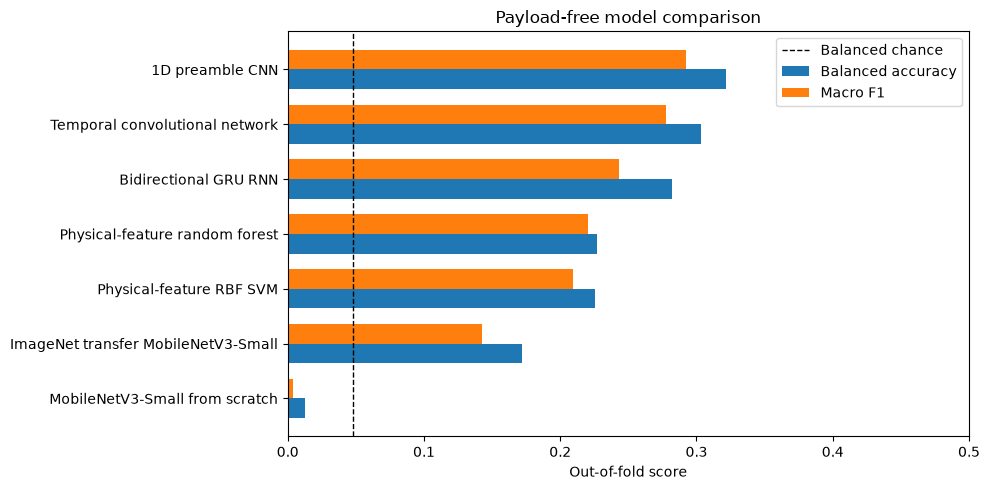

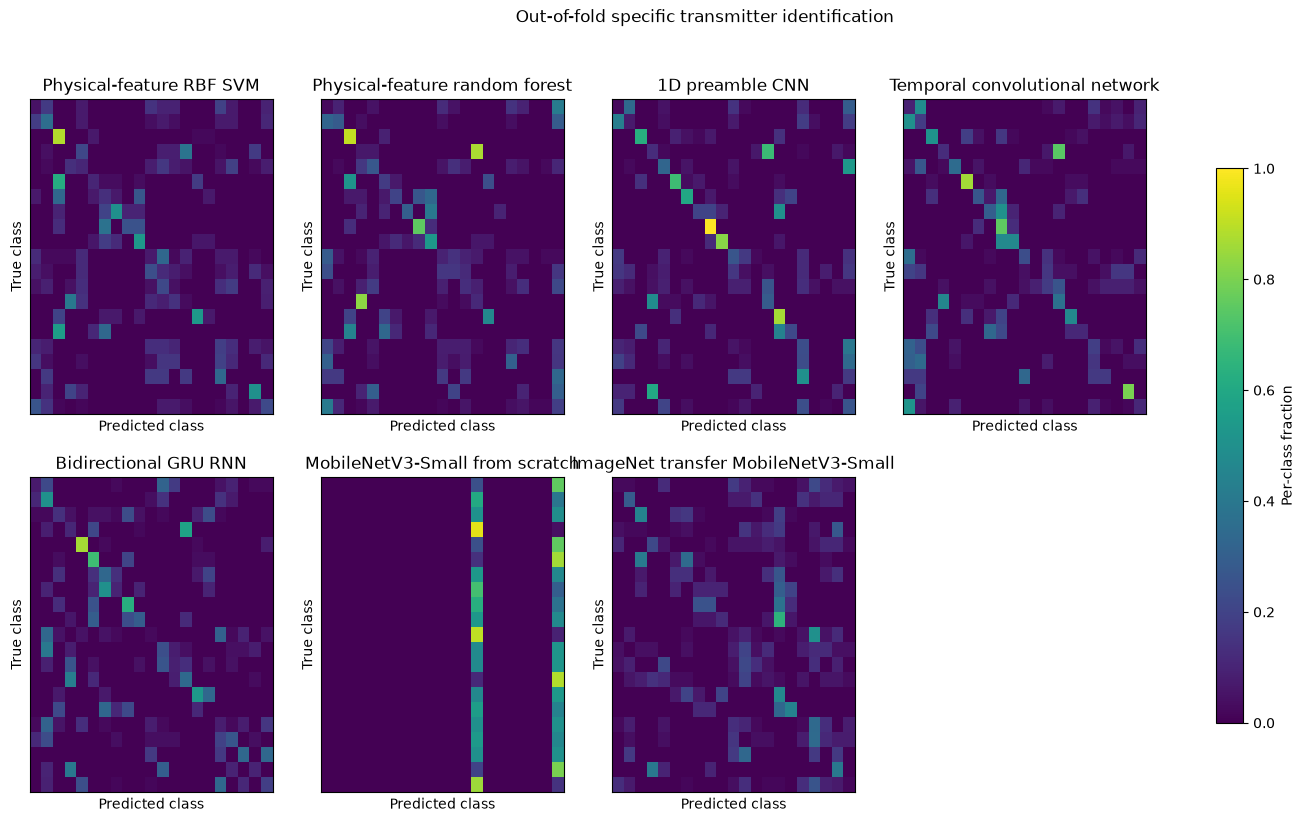

,experiment,model,input,architecture,weight_source,total_parameters,trainable_parameters,parameter_memory_mb,support_vectors,tree_nodes,fitted_size_mb
0,physical_feature_svm,Physical-feature RBF SVM,33 physical features,RBF SVM,training fold,NaN,NaN,NaN,279.0,NaN,0.126386
1,physical_feature_random_forest,Physical-feature random forest,33 physical features,"300 trees, minimum leaf 2",training fold,NaN,NaN,NaN,NaN,38303.0,9.025699
2,preamble_cnn,1D preamble CNN,2 x 80 I/Q,"3 convolution blocks: 32, 64, 96 channels",training fold,31733.0,31733.0,0.126932,NaN,NaN,0.126932
3,preamble_tcn,Temporal convolutional network,2 x 80 I/Q,"3 residual dilated blocks: dilation 1, 2, 4",training fold,43509.0,43509.0,0.174036,NaN,NaN,0.174036
4,preamble_gru_rnn,Bidirectional GRU RNN,2 x 80 I/Q,"1 bidirectional GRU layer, 64 units per direction",training fold,29077.0,29077.0,0.116308,NaN,NaN,0.116308
5,mobilenet_scratch,MobileNetV3-Small from scratch,3 x 80 x 80 recurrence image,"MobileNetV3-Small, random initialisation",training fold,1539381.0,1539381.0,6.157524,NaN,NaN,6.157524
6,imagenet_transfer_mobilenet,ImageNet transfer MobileNetV3-Small,3 x 80 x 80 recurrence image,MobileNetV3-Small ImageNet-1K features frozen,ImageNet-1K,1539381.0,612373.0,6.157524,NaN,NaN,6.157524


In [16]:
# Combined out-of-fold results.
overall_rows = []
for experiment in CONFIG["experiments"]:
    subset = predictions_df[predictions_df["experiment"] == experiment]
    overall_rows.append({
        "experiment": experiment,
        "model": MODEL_NAMES[experiment],
        **score_predictions(subset["true_class"], subset["predicted_class"]),
    })
overall_summary = pd.DataFrame(overall_rows).sort_values("balanced_accuracy", ascending=False).reset_index(drop=True)
display(overall_summary)

uniform_chance = 1.0 / len(class_names)
majority_accuracy = model_metadata["icao"].value_counts(normalize=True).max()
print(f"Balanced chance reference: {uniform_chance:.3f}")
print(f"Majority-class accuracy reference: {majority_accuracy:.3f}")
print("Validation:", evidence_grade)

fig, axis = plt.subplots(figsize=(10, 5))
plot_data = overall_summary.sort_values("balanced_accuracy")
y_pos = np.arange(len(plot_data))
axis.barh(y_pos - 0.18, plot_data["balanced_accuracy"], height=0.36, label="Balanced accuracy")
axis.barh(y_pos + 0.18, plot_data["macro_f1"], height=0.36, label="Macro F1")
axis.axvline(uniform_chance, color="black", linestyle="--", linewidth=1, label="Balanced chance")
axis.set_yticks(y_pos, plot_data["model"])
axis.set_xlim(0, max(0.5, 1.1 * plot_data[["balanced_accuracy", "macro_f1"]].to_numpy().max()))
axis.set_xlabel("Out-of-fold score")
axis.legend()
axis.set_title("Payload-free model comparison")
plt.tight_layout()
fig.savefig(figure_dir / "06_09_26_model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for axis, experiment in zip(axes.ravel(), CONFIG["experiments"]):
    subset = predictions_df[predictions_df["experiment"] == experiment]
    cm = confusion_matrix(subset["true_class"], subset["predicted_class"], labels=class_names, normalize="true")
    image = axis.imshow(cm, vmin=0, vmax=1, aspect="auto")
    axis.set_title(MODEL_NAMES[experiment])
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")
    axis.set_xticks([])
    axis.set_yticks([])

    single_fig, single_axis = plt.subplots(figsize=(6, 5))
    single_image = single_axis.imshow(cm, vmin=0, vmax=1, aspect="auto")
    single_axis.set_title(MODEL_NAMES[experiment])
    single_axis.set_xlabel("Predicted class")
    single_axis.set_ylabel("True class")
    single_axis.set_xticks([])
    single_axis.set_yticks([])
    single_fig.colorbar(single_image, ax=single_axis, label="Per-class fraction")
    single_fig.tight_layout()
    single_fig.savefig(figure_dir / f"06_09_26_{experiment}_confusion.png", dpi=180, bbox_inches="tight")
    plt.close(single_fig)

axes.ravel()[-1].axis("off")
fig.colorbar(image, ax=axes.ravel().tolist(), label="Per-class fraction", shrink=0.8)
fig.suptitle("Out-of-fold specific transmitter identification")
fig.savefig(figure_dir / "06_09_26_confusion_matrices.png", dpi=180, bbox_inches="tight")
plt.show()

complexity_summary = (
    complexity_df.drop(columns="fold")
    .groupby("experiment", as_index=False)
    .mean(numeric_only=True)
)
model_specs_complete = pd.DataFrame([
    {
        "experiment": experiment,
        "model": MODEL_NAMES[experiment],
        "input": (
            "33 physical features" if "physical_feature" in experiment
            else "3 x 80 x 80 recurrence image" if "mobilenet" in experiment
            else "2 x 80 I/Q"
        ),
        "architecture": (
            "RBF SVM" if experiment == "physical_feature_svm"
            else f"{CONFIG['random_forest_trees']} trees, minimum leaf 2" if experiment == "physical_feature_random_forest"
            else "3 convolution blocks: 32, 64, 96 channels" if experiment == "preamble_cnn"
            else "3 residual dilated blocks: dilation 1, 2, 4" if experiment == "preamble_tcn"
            else "1 bidirectional GRU layer, 64 units per direction" if experiment == "preamble_gru_rnn"
            else "MobileNetV3-Small, random initialisation" if experiment == "mobilenet_scratch"
            else "MobileNetV3-Small ImageNet-1K features frozen"
        ),
        "weight_source": "ImageNet-1K" if experiment == "imagenet_transfer_mobilenet" else "training fold",
    }
    for experiment in CONFIG["experiments"]
]).merge(complexity_summary, on="experiment", how="left")
display(model_specs_complete)


In [17]:
# Save results and audit files.
output_dir = CONFIG["artifact_dir"]
results_df.to_csv(output_dir / "grouped_fold_results.csv", index=False)
overall_summary.to_csv(output_dir / "aggregate_results.csv", index=False)
predictions_df.to_csv(output_dir / "out_of_fold_predictions.csv", index=False)
fold_audit.to_csv(output_dir / "fold_leakage_audit.csv", index=False)
learning_input_audit.to_csv(output_dir / "model_input_audit.csv", index=False)
model_specs_complete.to_csv(output_dir / "model_specs.csv", index=False)

assignments = model_metadata[["record_index", "timestamp", "icao", "group_id"]].copy()
assignments["validation_fold"] = -1
for fold_number, (_, val_idx) in enumerate(folds, start=1):
    assignments.loc[val_idx, "validation_fold"] = fold_number
assignments.to_csv(output_dir / "fold_assignments.csv", index=False)

with (output_dir / "label_mapping.json").open("w") as stream:
    json.dump({int(index): label for index, label in enumerate(class_names)}, stream, indent=2)

serialisable_config = {key: (str(value) if isinstance(value, Path) else value) for key, value in CONFIG.items()}
with (output_dir / "experiment_config.json").open("w") as stream:
    json.dump(serialisable_config, stream, indent=2)

print("Saved:", output_dir.resolve())


Saved: /Users/calebrodgers/Desktop/ml/adsb_specific_transmitter_outputs


## Short notes

- Use balanced accuracy and macro F1 because the class counts differ.
- Above-chance performance shows class-correlated preamble information in this capture.
- A different flight pass or day is still needed to separate transmitter properties from Doppler, range, SNR and channel effects.
- ImageNet is a different domain. Compare transfer MobileNet with the same architecture trained from scratch.

MobileNetV3-Small weights: [official Torchvision documentation](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.mobilenet_v3_small.html).
